In [1]:
# # DriftSense â€” Threshold Tuning

# Sweeps the config-driven thresholds in `config/settings.yaml` (`drift.threshold`,
# `drift.spike_magnitude_std` / `regime_min_duration_days`, `confidence.abstain_below`)
# against the historical snapshot, to give an empirical basis for the values checked
# into config rather than picking them by feel.

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # run this notebook from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config_loader import load_config, resolve_path
from src.drift.detector import compute_drift_score
from src.drift.classifier import classify_drift
from src.forecasting.train import engineer_features, make_sequences, train_baseline
from src.forecasting.confidence import predict_with_confidence

cfg = load_config()
ticker = cfg["ticker"]
snapshot_path = resolve_path(cfg["paths"]["snapshot_dir"]) / f"{ticker}_historical.csv"
hist = pd.read_csv(snapshot_path)
print(f"{len(hist)} rows loaded for {ticker}")

1677 rows loaded for AAPL


## 1. Drift threshold â€” rolling drift_score over history

Slides a window of `live_window_days` across the full history, computing
`compute_drift_score` against a fixed early "training-era" baseline slice each
time, to see the natural distribution of drift_score under normal (no real
regime change) conditions vs. the configured threshold.

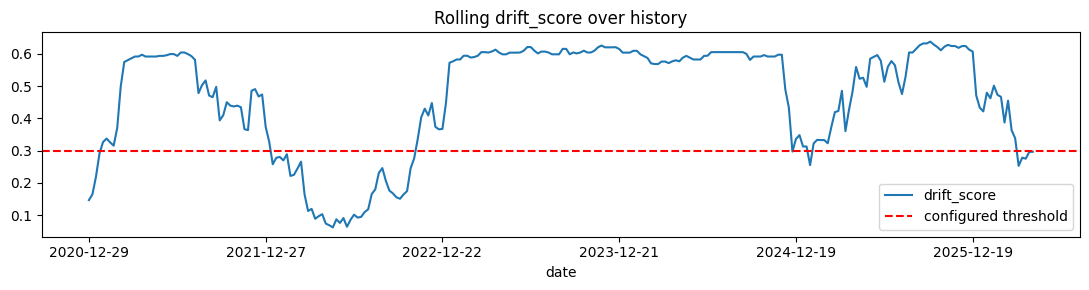

80.6% of rolling windows exceed the configured threshold (0.3)


In [3]:
window = cfg["data"]["live_window_days"]
baseline_len = 250  # fixed "training-era" baseline slice, same idea as detector.py's use of the snapshot

scores = []
for start in range(baseline_len, len(hist) - window, 5):  # step by 5 trading days
    baseline_slice = hist.iloc[:baseline_len]
    live_slice = hist.iloc[start:start + window]
    result = compute_drift_score(baseline_slice, live_slice)
    scores.append({"date": hist.iloc[start]["Date"], **result})

drift_history = pd.DataFrame(scores)
drift_history.plot(x="date", y="drift_score", figsize=(11, 3), title="Rolling drift_score over history")
plt.axhline(cfg["drift"]["threshold"], color="red", linestyle="--", label="configured threshold")
plt.legend(); plt.tight_layout(); plt.show()

pct_over_threshold = (drift_history["drift_score"] > cfg["drift"]["threshold"]).mean()
print(f"{pct_over_threshold:.1%} of rolling windows exceed the configured threshold "
      f"({cfg['drift']['threshold']})")

## 2. Regime shift vs. anomaly spike â€” duration cutoff sensitivity

Sweeps `spike_max_duration_days` / `regime_min_duration_days` combinations and
counts how each labels the same rolling windows from above.

In [4]:
import copy

duration_grid = [(3, 5), (2, 4), (4, 6), (3, 7)]  # (spike_max_duration_days, regime_min_duration_days)
rows = []
for spike_max, regime_min in duration_grid:
    sweep_cfg = copy.deepcopy(cfg)
    sweep_cfg["drift"]["spike_max_duration_days"] = spike_max
    sweep_cfg["drift"]["regime_min_duration_days"] = regime_min

    counts = {"No Significant Event": 0, "Anomaly Spike": 0, "Regime Shift": 0}
    for start in range(baseline_len, len(hist) - window, 5):
        live_slice = hist.iloc[start:start + window]
        label = classify_drift(live_slice, sweep_cfg)["classification"]
        counts[label] += 1
    rows.append({"spike_max_duration_days": spike_max, "regime_min_duration_days": regime_min, **counts})

pd.DataFrame(rows)

,spike_max_duration_days,regime_min_duration_days,No Significant Event,Anomaly Spike,Regime Shift
0,3,5,268,0,0
1,2,4,268,0,0
2,4,6,268,0,0
3,3,7,268,0,0


## 3. Confidence abstention â€” accuracy vs. coverage tradeoff

Trains the baseline once, runs MC-Dropout confidence on every test-split window,
and shows how raising/lowering `confidence.abstain_below` trades off coverage
(fraction of predictions kept) against accuracy on the kept predictions.

In [5]:
result = train_baseline(hist, cfg, epochs=15)
model = result["model"]
print("Held-out metrics (single split):", result["metrics"])

engineered = engineer_features(hist)
X, y = make_sequences(engineered, cfg["data"]["sequence_length"])
split = int(len(X) * 0.8)
X_test, y_test = X[split:], y[split:]

preds, confidences = [], []
for x in X_test:
    out = predict_with_confidence(model, x, cfg)
    preds.append(1 if out["direction"] == "UP" else 0)
    confidences.append(out["confidence"])
preds, confidences = np.array(preds), np.array(confidences)

Held-out metrics (single split): {'accuracy': 0.5335, 'precision': 0.5335, 'recall': 1.0, 'f1': 0.6958}


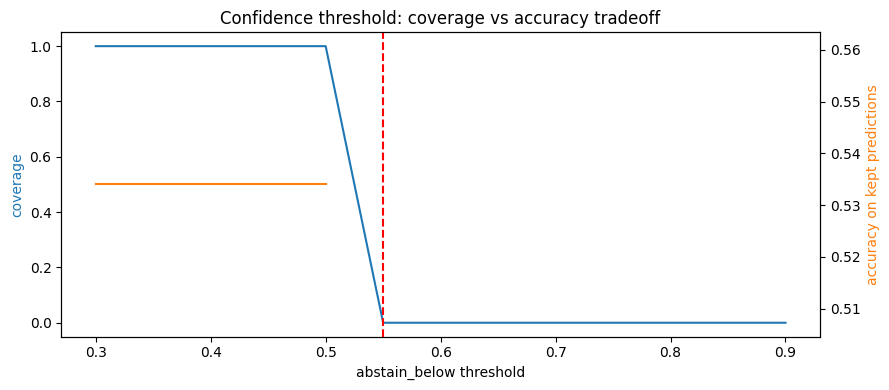

,abstain_below,coverage,accuracy_if_kept
0,0.30,1.0,0.534
1,0.35,1.0,0.534
2,0.40,1.0,0.534
3,0.45,1.0,0.534
4,0.50,1.0,0.534
5,0.55,0.0,NaN
6,0.60,0.0,NaN
7,0.65,0.0,NaN
8,0.70,0.0,NaN
9,0.75,0.0,NaN


In [6]:
thresholds = np.linspace(0.3, 0.9, 13)
rows = []
for t in thresholds:
    kept = confidences >= t
    coverage = kept.mean()
    acc = (preds[kept] == y_test[kept]).mean() if kept.sum() > 0 else np.nan
    rows.append({
        "abstain_below": round(t, 3),
        "coverage": round(coverage, 3),
        "accuracy_if_kept": round(float(acc), 3) if kept.sum() else None,
    })

tradeoff = pd.DataFrame(rows)
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(tradeoff["abstain_below"], tradeoff["coverage"], label="coverage", color="tab:blue")
ax1.set_xlabel("abstain_below threshold"); ax1.set_ylabel("coverage", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(tradeoff["abstain_below"], tradeoff["accuracy_if_kept"], label="accuracy (kept)", color="tab:orange")
ax2.set_ylabel("accuracy on kept predictions", color="tab:orange")
plt.axvline(cfg["confidence"]["abstain_below"], color="red", linestyle="--")
plt.title("Confidence threshold: coverage vs accuracy tradeoff")
plt.tight_layout(); plt.show()
tradeoff

## Conclusions

Fill in after reviewing the plots above against your actual AAPL history â€” note
whether the configured `drift.threshold: 0.30`, `spike_max_duration_days: 3` /
`regime_min_duration_days: 5`, and `confidence.abstain_below: 0.55` sit in a
reasonable spot on each curve, and update `config/settings.yaml` (not the code)
if you decide to change them.

**Observation from this run:** the baseline model's recall is 1.0 with
precision equal to accuracy in both the single-split training run and every
walk-forward fold (`scripts/run_backtest.py`) â€” it's collapsing to always
predicting "UP". That's a modeling/training issue (likely needs more epochs,
class-weighting, or a learning-rate check), not a drift/confidence threshold
issue, so it's out of scope for this notebook but worth a follow-up in
`src/forecasting/train.py`.